# Module 2 POC Training -- FIRE + LongDRScreening + Tianjin

Runs `train_module2_poc.py` against all three Module 2 data sources at once: FIRE and
LongDRScreening (placeholder Stage-2 conditioning unless a Module 1 cache says otherwise,
same as notebook 04) plus Tianjin (real clinical DR grade conditioning, resolved per-eye --
see notebook 05).

The Generator (`DRForestGAN-v2/base_model.py`) uses AdaIN stage conditioning in its
bottleneck, additive to the original channel-concat conditioning. Training pairs can use a
pre-registered, baseline-aligned follow-up image from `module1/train_registration.py` instead
of the raw one, and after training this notebook runs `evaluate_trajectory.py` to report
per-cascade-step FID/PSNR/SSIM against Tianjin's real follow-up images -- not just a
single-step number. A checkpoint from before the AdaIN change will not load into the current
Generator.

**Run this after notebook 04** (FIRE/LongDR Module 1 caches) **and notebook 05** (Tianjin
Module 1 cache + laterality resolution) **have both finished** -- this notebook only reads
their cache outputs from Drive, it doesn't rebuild them.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import getpass, os
GITHUB_TOKEN = getpass.getpass('GitHub Personal Access Token (repo scope): ')

REPO_OWNER = 'Mieka068'
REPO_NAME = 'DRProgression'
REPO_BRANCH = 'main'  # <-- change if the code you need (e.g. this Tianjin work) isn't merged yet
REPO_CODE_SUBDIR = 'M2-DRProgression-VerM-module1-fgadr-poc'

DRIVE_DATA_DIR = '/content/drive/MyDrive/Thesis_Datasets'
assert os.path.isdir(DRIVE_DATA_DIR), f"Not found: {DRIVE_DATA_DIR}"
CACHE_DIR = os.path.join(DRIVE_DATA_DIR, 'module1_cache')
for _name in ['module1_outputs_fire.pt', 'module1_outputs_longdr.pt', 'module1_outputs_tianjin.pt']:
    _p = os.path.join(CACHE_DIR, _name)
    assert os.path.isfile(_p), (
        f"Not found: {_p} -- run notebook 04 (FIRE/LongDR) and notebook 05 (Tianjin) first."
    )
    print('✓', _p)

Mounted at /content/drive
GitHub Personal Access Token (repo scope): ··········
✓ /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt
✓ /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt
✓ /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt


In [2]:
# Unzip the three raw datasets locally (train_module2_poc.py's loaders read images directly
# at training time, not just at cache-build time). Same unzip conventions as notebooks 01/04/05.
import glob, shutil

os.makedirs('/content/data', exist_ok=True)
%cd /content/data
!unzip -q -n "$DRIVE_DATA_DIR/FIRE_dataset.zip"
!unzip -q -n "$DRIVE_DATA_DIR/LongDRScreening_20150209.zip" -d LongDRScreening_20150209
!unzip -q -n "$DRIVE_DATA_DIR/retinal-dr-longitudinal.zip" -d _tianjin_extract_raw

_manifest_candidates = glob.glob('/content/data/_tianjin_extract_raw/**/corrected_manifest.csv', recursive=True)
assert _manifest_candidates, 'No corrected_manifest.csv found -- see notebook 05 for troubleshooting.'
_tianjin_root = os.path.dirname(_manifest_candidates[0])
TIANJIN_DIR = '/content/data/retinal-dr-longitudinal'
if _tianjin_root != TIANJIN_DIR and not os.path.exists(TIANJIN_DIR):
    os.symlink(_tianjin_root, TIANJIN_DIR)

print('FIRE Images present   :', os.path.isdir('/content/data/FIRE_dataset/FIRE/Images'))
print('LongDR norm present   :', os.path.isdir('/content/data/LongDRScreening_20150209/FundusImagesNormalized'))
print('Tianjin manifest found:', os.path.isfile(os.path.join(TIANJIN_DIR, 'corrected_manifest.csv')))

/content/data
FIRE Images present   : True
LongDR norm present   : True
Tianjin manifest found: True


In [3]:
# Clone this repo. Skips cleanly if already cloned in this runtime.
%cd /content
if not os.path.isdir(f'/content/{REPO_NAME}'):
    !git clone --branch {REPO_BRANCH} https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git {REPO_NAME}

REPO_CODE_DIR = f'/content/{REPO_NAME}/{REPO_CODE_SUBDIR}'
assert os.path.isdir(REPO_CODE_DIR), f"Not found: {REPO_CODE_DIR} -- check REPO_BRANCH/REPO_CODE_SUBDIR above"

%cd {REPO_CODE_DIR}
!pip install -q pandas openpyxl segmentation-models-pytorch torchmetrics torch-fidelity opencv-python-headless

/content
Cloning into 'DRProgression'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 200 (delta 98), reused 102 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 1.19 MiB | 9.97 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.6 MB/s eta 0:00:00


In [4]:
# Laterality resolution: Organized_Data of Patients.xlsx grades DR per eye (OS/OD), not per
# patient, and corrected_manifest.csv doesn't say which eye a row is -- tianjin_dataset.py /
# module3/dataset.py both require laterality_resolved.csv to exist in TIANJIN_DIR before they
# can run. Reuse a Drive-persisted copy if one already exists (resolving ~1,100 images takes a
# few minutes); otherwise compute it fresh here and persist it to Drive for next time.
LATERALITY_DRIVE_PATH = os.path.join(DRIVE_DATA_DIR, 'module1_cache', 'laterality_resolved.csv')
LATERALITY_LOCAL_PATH = os.path.join(TIANJIN_DIR, 'laterality_resolved.csv')

if os.path.isfile(LATERALITY_DRIVE_PATH):
    import shutil
    shutil.copy(LATERALITY_DRIVE_PATH, LATERALITY_LOCAL_PATH)
    print(f'✓ Reused laterality_resolved.csv from Drive: {LATERALITY_DRIVE_PATH}')
else:
    %cd {REPO_CODE_DIR}
    !python module1/resolve_eye_laterality.py --dataset-dir "{TIANJIN_DIR}"
    # Read the printed same-eye disagreement rate above before trusting this for training --
    # see resolve_eye_laterality.py's module docstring (>5% disagreement means the heuristic
    # needs tuning).
    os.makedirs(os.path.dirname(LATERALITY_DRIVE_PATH), exist_ok=True)
    import shutil
    shutil.copy(LATERALITY_LOCAL_PATH, LATERALITY_DRIVE_PATH)
    print(f'✓ Computed and persisted laterality_resolved.csv to Drive: {LATERALITY_DRIVE_PATH}')

✓ Reused laterality_resolved.csv from Drive: /content/drive/MyDrive/Thesis_Datasets/module1_cache/laterality_resolved.csv


In [5]:
# Trains the training-only affine registration network once, and pre-warps every
# baseline<->follow-up pair (all 3 sources) so train_module2_poc.py can condition on
# baseline-aligned follow-up images instead of raw ones. Regenerated each session (a few
# minutes at POC scale) -- consider persisting registration_net.ckpt/registered_followups.pt
# to Drive under module1_cache/ if this becomes a bottleneck.
%cd {REPO_CODE_DIR}/module1
!python train_registration.py \
    --fire-dir /content/data/FIRE_dataset \
    --longdr-dir /content/data/LongDRScreening_20150209 \
    --tianjin-dir "{TIANJIN_DIR}" \
    --num-epochs 10 \
    --checkpoint-out ./registration_net.ckpt \
    --cache-out ./registered_followups.pt

REGISTRATION_CACHE = f'{REPO_CODE_DIR}/module1/registered_followups.pt'

/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc/module1
Training-only affine registration network
Device: cuda

[1/3] Loading FIRE + LongDRScreening + Tianjin pairs...
  Searching: /content/data/FIRE_dataset/FIRE/Images
✓ Found 14 pairs in FIRE Category A
✓ Found 559 pairs in LongDRScreening (FundusImagesNormalized)
  Reading grades from sheet 'Baseline': patient_id <- 'ID', OS <- 'OS Grade（1=No Apparent Retinopathy；2=Mild Non-Proliferative Diabetic Retinopathy；3=Moderate Non-Proliferative Diabetic Retinopathy；4=Severe Non-Proliferative Diabetic Retinopathy；5=Proliferative Diabetic Retinopathy；6=After laser；7=Missing）', OD <- 'OD Grade（1=No Apparent Retinopathy；2=Mild Non-Proliferative Diabetic Retinopathy；3=Moderate Non-Proliferative Diabetic Retinopathy；4=Severe Non-Proliferative Diabetic Retinopathy；5=Proliferative Diabetic Retinopathy；6=After laser；7=Missing）', worse-eye <- 'At-risk Eye Grade（Worse eye）'
  Eye-specific grade resolved for 856/1115 rows (259 fell back 

In [6]:
# --fire-dir / --longdr-dir / --tianjin-dir MUST be passed explicitly: train_module2_poc.py's
# own argparse defaults resolve relative to the cloned repo's working directory, not where the
# data actually lives on the Colab VM (see combined_dataset.py / train_module2_poc.py docstrings).
%cd {REPO_CODE_DIR}
!python train_module2_poc.py \
    --fire-dir /content/data/FIRE_dataset \
    --longdr-dir /content/data/LongDRScreening_20150209 \
    --tianjin-dir "{TIANJIN_DIR}" \
    --fire-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt \
    --longdr-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt \
    --tianjin-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt \
    --registration-cache "{REGISTRATION_CACHE}" \
    --num-epochs 5

/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc
Module 2 POC training (real Module 1 conditioning)
Device: cuda
fire_module1_cache_path: /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt
longdr_module1_cache_path: /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt
tianjin_dir: /content/data/retinal-dr-longitudinal
tianjin_module1_cache_path: /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt

[1/4] Loading combined dataset (with real Module 1 conditioning where cached)...
✓ Loaded Module 1 cache: 268 images (/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt)
✓ Loaded registration cache: 1671 pairs (/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc/module1/registered_followups.pt)
  Searching: /content/data/FIRE_dataset/FIRE/Images
✓ Found 14 pairs in FIRE Category A
✓ FIRE: 14 pairs
✓ Loaded Module 1 cache: 1120 images (/content/drive/MyDrive/Thesis

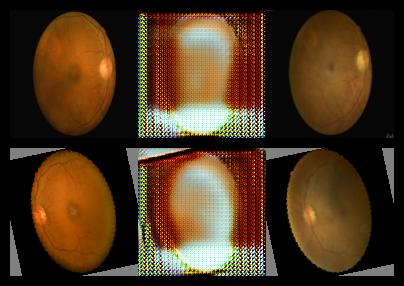

{
  "num_epochs": 5,
  "num_pairs": 1671,
  "effective_samples": 6684,
  "g_lr": 0.0002,
  "d_lr": 0.0002,
  "beta1": 0.0,
  "beta2": 0.9,
  "fire_module1_cache_path": "/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_fire.pt",
  "longdr_module1_cache_path": "/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_longdr.pt",
  "tianjin_dir": "/content/data/retinal-dr-longitudinal",
  "tianjin_module1_cache_path": "/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt",
  "registration_cache_path": "/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc/module1/registered_followups.pt",
  "metrics": {
    "psnr": 7.745455741882324,
    "ssim": 0.12574800848960876,
    "fid": 163.38522338867188,
    "n_batches_used": 5
  },
  "total_time_min": 57.904278083642325
}


In [7]:
from IPython.display import Image as IPImage, display
import glob, json, os

samples = sorted(glob.glob(f'{REPO_CODE_DIR}/training_samples_poc/epoch_*.jpg'))
if samples:
    display(IPImage(samples[-1]))
else:
    print('No training_samples_poc/epoch_*.jpg found -- the training cell above did not finish. Read its output.')

rp = f'{REPO_CODE_DIR}/DRForestGAN-v2/stargan/models_poc/poc_results.json'
print(json.dumps(json.load(open(rp)), indent=2) if os.path.isfile(rp) else f'{rp} not found')

In [8]:
# Locate the same Module 1 checkpoints notebooks 04/05 already found on Drive -- the cascade
# re-segments/re-grades each synthesized step with Module 1 itself (not just the GAN), so
# evaluate_trajectory.py needs these too, not just the module1_cache .pt files.
import glob

SEG_DIR   = '/content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation'
CLS_SAVES = '/content/drive/MyDrive/Thesis_Datasets/module1_runs/classification/fgadr/saves'

_pref  = ['final_weights.pt', 'best_validation_weights.pt']
_cands = [os.path.join(CLS_SAVES, n) for n in _pref] + sorted(
    glob.glob(os.path.join(CLS_SAVES, '*.pt')), key=os.path.getmtime, reverse=True)
CLS_CKPT = next((p for p in _cands if os.path.isfile(p)), None)
assert CLS_CKPT, f"No classifier .pt in {CLS_SAVES} -- run notebook 02 first"

EX_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_ex', 'model_2.pth.tar')
MA_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_ma', 'model_2.pth.tar')
for _p in (CLS_CKPT, EX_CKPT, MA_CKPT):
    assert os.path.isfile(_p), f"missing checkpoint: {_p} -- run notebooks 02/03 first"
print('classifier :', CLS_CKPT)
print('EX seg     :', EX_CKPT)
print('MA seg     :', MA_CKPT)
# HE/SE checkpoints -- included automatically once they exist on Drive, omitted otherwise
# (apply_to_progression_data.py/evaluate_trajectory.py both leave a lesion channel out rather
# than fail if no checkpoint is passed for it).
HE_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_he', 'model_2.pth.tar')
SE_CKPT = os.path.join(SEG_DIR, 'models_FGADR_NO_TATL_se', 'model_2.pth.tar')
print('HE seg     :', HE_CKPT if os.path.isfile(HE_CKPT) else 'not trained yet')
print('SE seg     :', SE_CKPT if os.path.isfile(SE_CKPT) else 'not trained yet')

classifier : /content/drive/MyDrive/Thesis_Datasets/module1_runs/classification/fgadr/saves/final_weights.pt
EX seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_ex/model_2.pth.tar
MA seg     : /content/drive/MyDrive/Thesis_Datasets/module1_runs/segmentation/models_FGADR_NO_TATL_ma/model_2.pth.tar
HE seg     : not trained yet
SE seg     : not trained yet


In [9]:
# Per-cascade-step FID/PSNR/SSIM against Tianjin's real follow-up images (the only source with
# a real grade on both baseline and follow-up -- FIRE/LongDR can't participate, see
# evaluate_trajectory.py's module docstring), plus Module 1's own re-grading consistency at
# every cascade step (generate, re-segment, re-grade, feed forward). The single-step metrics
# from the training cell above don't report this.
%cd {REPO_CODE_DIR}
_extra_seg_args = ''
if os.path.isfile(HE_CKPT):
    _extra_seg_args += f' --seg-checkpoint HE={HE_CKPT}'
if os.path.isfile(SE_CKPT):
    _extra_seg_args += f' --seg-checkpoint SE={SE_CKPT}'

!python evaluate_trajectory.py \
    --tianjin-dir "{TIANJIN_DIR}" \
    --tianjin-module1-cache /content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt \
    --generator-checkpoint ./DRForestGAN-v2/stargan/models_poc/final-G.ckpt \
    --classifier-checkpoint "{CLS_CKPT}" \
    --seg-checkpoint EX="{EX_CKPT}" --seg-checkpoint MA="{MA_CKPT}"{_extra_seg_args} \
    --out ./trajectory_eval_results.json

import json as _json
print(_json.dumps(_json.load(open(f'{REPO_CODE_DIR}/trajectory_eval_results.json')), indent=2))

/content/DRProgression/M2-DRProgression-VerM-module1-fgadr-poc
Device: cuda

[1/4] Loading Tianjin survival dataset (source of real baseline+follow-up grade pairs)...
✓ Loaded Module 1 cache: 1234 images (/content/drive/MyDrive/Thesis_Datasets/module1_cache/module1_outputs_tianjin.pt)
  Total eye-pairs in corrected_manifest.csv: 1115
  Baseline sheet 'Baseline': patient_id <- 'ID', OS <- 'OS Grade（1=No Apparent Retinopathy；2=Mild Non-Proliferative Diabetic Retinopathy；3=Moderate Non-Proliferative Diabetic Retinopathy；4=Severe Non-Proliferative Diabetic Retinopathy；5=Proliferative Diabetic Retinopathy；6=After laser；7=Missing）', OD <- 'OD Grade（1=No Apparent Retinopathy；2=Mild Non-Proliferative Diabetic Retinopathy；3=Moderate Non-Proliferative Diabetic Retinopathy；4=Severe Non-Proliferative Diabetic Retinopathy；5=Proliferative Diabetic Retinopathy；6=After laser；7=Missing）', worse-eye <- 'At-risk Eye Grade（Worse eye）'
  Follow-up sheet '2 year follow-up': patient_id <- 'ID', OS <- 'OS Gra

## Caveats

- Same POC-scale caveats as notebook 04 (5 epochs, Adam settings tuned to lr=2e-4, β1=0.0,
  β2=0.9, EX+MA-only segmentation conditioning by default -- HE/SE are picked up automatically
  once trained).
- Tianjin adds a real clinical grade conditioning source, resolved per-eye. The
  ETDRS(1-5)->ICDR(0-4) offset is a numeric relabeling, not a claim that ETDRS and ICDR are
  clinically equivalent staging criteria (see `tianjin_dataset.py`).
- FIRE and LongDR still fall back to placeholder Stage-2 conditioning wherever no Module 1
  cache entry exists for a given image -- this run does not change that.
- AdaIN stage conditioning, a training-only registration network, and autoregressive
  multi-stage cascade generation run on top of the DRForecastGAN base. The cascade follows a
  4-step loop per stage: generate, re-segment with Module 1, re-grade with Module 1 as a
  consistency check, feed forward.
- The per-cascade-step numbers above come from very few real Tianjin progression pairs at POC
  scale; read the n_pairs in each bucket before treating any step's FID/PSNR/SSIM as reliable.
  Buckets with too few pairs report FID as null rather than a misleading number.
- `module1_consistency` (does the synthesized image at step N read as stage N to Module 1's
  own grader?) is a separate signal from PSNR/SSIM/FID -- a low rate could mean the generator
  produced something implausible, or that Module 1's grader is unreliable on
  out-of-distribution synthesized images, or both.
- The registration network's warp quality has not been visually audited here -- inspect a few
  `registered_followups.pt` entries before trusting that pre-registration measurably helped.
- Module 3 (not trained in this notebook) also conditions on the baseline eye's own severity
  grade, not just the LBS stratum -- see notebook 07.